# Airline Sentiment Classification with an ANN

Three-class sentiment classification (negative / neutral / positive) of tweets about six US airlines, using a feed-forward neural network.

This notebook calls the code, shows the results and explains each decision.

## Setup

In [1]:
import sys
from pathlib import Path


project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src").is_dir())
sys.path.insert(0, str(project_root))

import torch
import torch.nn as nn

from src.data_loader import load_raw_data, inspect_data
from src.eda import (
    count_noise_patterns, print_vocabulary_stats, plot_class_distribution,
    plot_tweet_lengths, plot_top_words, plot_wordcloud,
)
from src.preprocessing import preprocess_dataset
from src.vectorizers import encode_labels, split_data, build_tfidf_features, build_word2vec_features
from src.model import ANN
from src.train import set_seed, make_loaders
from src.experiments import run_experiment, compare_experiments
from src.evaluate import plot_loss_curves, evaluate_model, plot_confusion_matrix

set_seed()

## 1. Data Preprocessing and EDA

### 1.1 Load the dataset and check its quality

In [2]:
df_raw = load_raw_data()
inspect_data(df_raw)

Loaded 14640 rows and 15 columns from Tweets.csv

--- STRUCTURE ---
                                dtype  non_null  missing  unique
tweet_id                        int64     14640        0   14485
airline_sentiment                 str     14640        0       3
airline_sentiment_confidence  float64     14640        0    1023
negativereason                    str      9178     5462      10
negativereason_confidence     float64     10522     4118    1410
airline                           str     14640        0       6
airline_sentiment_gold            str        40    14600       3
name                              str     14640        0    7701
negativereason_gold               str        32    14608      13
retweet_count                   int64     14640        0      18
text                              str     14640        0   14427
tweet_coord                       str      1019    13621     832
tweet_created                     str     14640        0   14247
tweet_location        

### 1.2 Class distribution

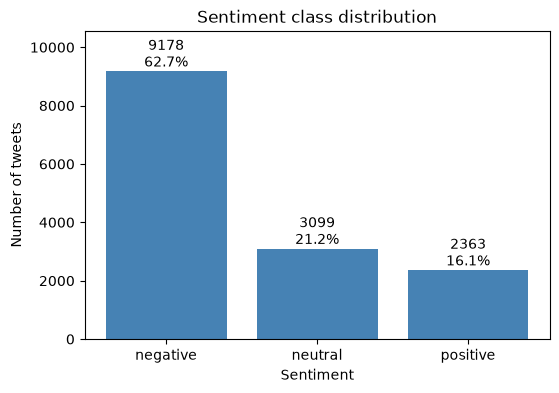

In [3]:
plot_class_distribution(df_raw)

### 1.3 Tweet length

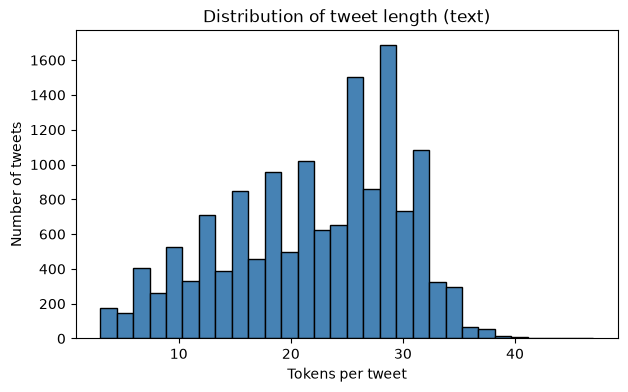

Mean 22.0 | Median 23 | Min 3 | Max 47


In [4]:
plot_tweet_lengths(df_raw)

### 1.4 Clean the raw text with useful rules



In [5]:
count_noise_patterns(df_raw)

@mentions        14640  (100.0%)
#hashtags         2375  ( 16.2%)
URLs              1173  (  8.0%)
HTML entities      720  (  4.9%)
HTML tags            0  (  0.0%)
digits            5868  ( 40.1%)
emojis             487  (  3.3%)


### 1.5 Most frequent words

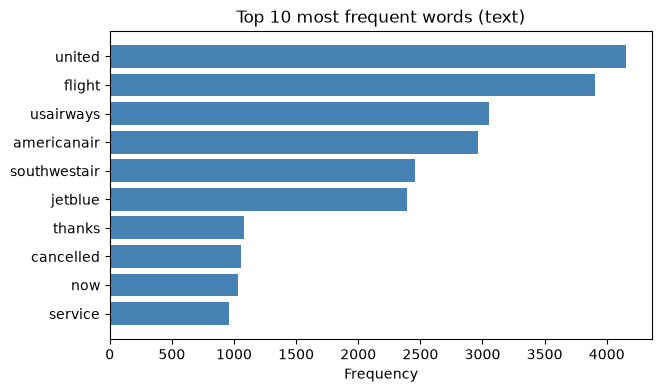

In [6]:
plot_top_words(df_raw)

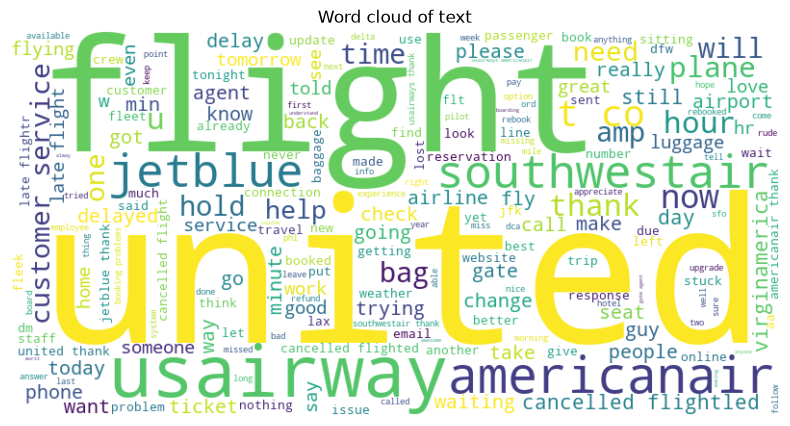

In [7]:
plot_wordcloud(df_raw)

Five of the ten most frequent words are airline names, coming from the `@mentions`.

### 1.6 Vocabulary size

In [8]:
print_vocabulary_stats(df_raw)

Total tokens          : 321599
Unique tokens         : 17012
Average tokens/tweet  : 22.0


**1.7. Cleaning and tokenization**

- Decode HTML entities
- Lowercase
- Expand contractions in order to keep negations
- Remove URLs
- Remove '#' and keep only the word
- Remove digits, emojis and punctuation, except '!', '?'
- Collapse whitespace

In [ ]:

df = preprocess_dataset(df_raw)
df[["text", "clean_text"]].head()

Rows in            : 14640
Empty after cleaning: 0
Duplicates removed : 436
Rows out           : 14204


,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus you have added commercials to the experie...
2,@VirginAmerica I didn't today... Must mean I n...,i did not today must mean i need to take anoth...
3,@VirginAmerica it's really aggressive to blast...,it is really aggressive to blast obnoxious ent...
4,@VirginAmerica and it's a really big bad thing...,and it is a really big bad thing about it


### 1.8 Verification

In [10]:
count_noise_patterns(df, "clean_text")
print_vocabulary_stats(df, "clean_text")

@mentions            0  (  0.0%)
#hashtags            0  (  0.0%)
URLs                 0  (  0.0%)
HTML entities        0  (  0.0%)
HTML tags            0  (  0.0%)
digits               0  (  0.0%)
emojis               0  (  0.0%)
Total tokens          : 246075
Unique tokens         : 11156
Average tokens/tweet  : 17.3


All seven noise patterns now match zero tweets. The vocabulary fell from 17,012 to 11,156
distinct tokens.

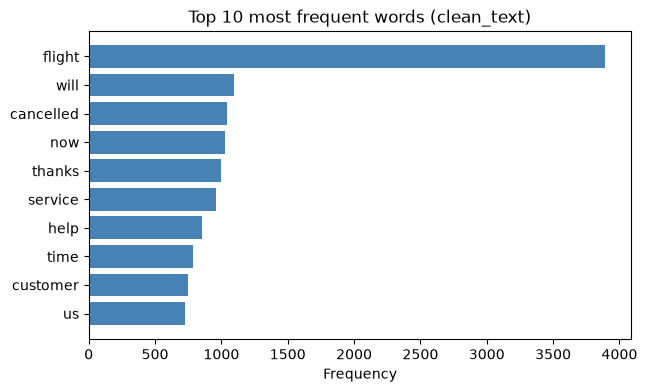

In [11]:
plot_top_words(df, "clean_text")

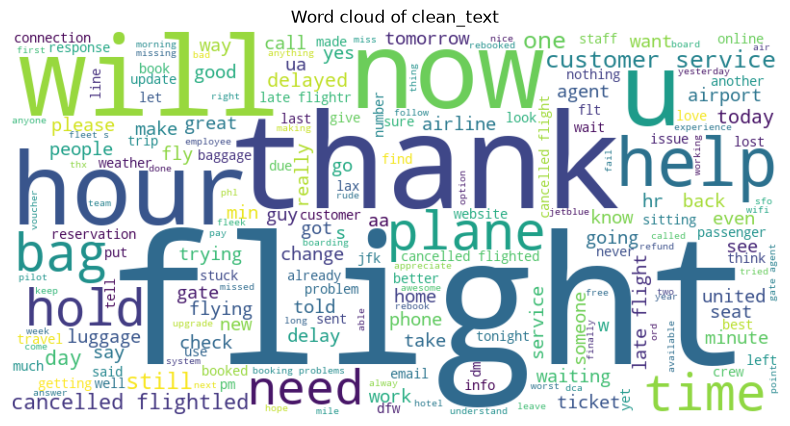

In [12]:
plot_wordcloud(df, "clean_text")

## 2. Feature Extraction

### 2.1 Label encoding and splitting

In [13]:
df, class_names = encode_labels(df)
train_df, val_df, test_df = split_data(df)
y_train, y_val, y_test = train_df["label"], val_df["label"], test_df["label"]

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Train 11363 | Validation 1420 | Test 1421



Stratified split in order to keep the class proportions.

In [14]:
X_tr, X_va, X_te, vectorizer = build_tfidf_features(
    train_df["clean_text"], val_df["clean_text"], test_df["clean_text"])
tfidf_loaders = make_loaders(X_tr, y_train, X_va, y_val, X_te, y_test)

W_tr, W_va, W_te, w2v = build_word2vec_features(
    train_df["tokens"], val_df["tokens"], test_df["tokens"])
w2v_loaders = make_loaders(W_tr, y_train, W_va, y_val, W_te, y_test)

TF-IDF: 5000 features | training matrix 227 MB
Word2Vec: 100 dimensions | vocabulary 5007 words




## 3. ANN Classifier

Two hidden layers of 256 units. Each is followed by batch normalisation, a ReLU activation and
dropout of 0.5.


In [15]:
print(ANN(input_dim=X_tr.shape[1]))

ANN(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=256, out_features=3, bias=True)
)


## 4. Experiments

 two representations, each with and without class weighting.

In [16]:
results = [
    run_experiment("tfidf_unweighted", tfidf_loaders, X_tr.shape[1], y_train, use_class_weights=False),
    run_experiment("tfidf_weighted", tfidf_loaders, X_tr.shape[1], y_train, use_class_weights=True),
    run_experiment("word2vec_unweighted", w2v_loaders, W_tr.shape[1], y_train, use_class_weights=False),
    run_experiment("word2vec_weighted", w2v_loaders, W_tr.shape[1], y_train, use_class_weights=True),
]


=== tfidf_unweighted ===
Epoch   1 | Train loss 1.0136 | Val loss 0.8492
Epoch   2 | Train loss 0.7177 | Val loss 0.6466
Epoch   3 | Train loss 0.5691 | Val loss 0.5770
Epoch   4 | Train loss 0.4644 | Val loss 0.5239
Epoch   5 | Train loss 0.3839 | Val loss 0.5027
Epoch   6 | Train loss 0.3130 | Val loss 0.5014
Epoch   7 | Train loss 0.2579 | Val loss 0.4964
Epoch   8 | Train loss 0.2191 | Val loss 0.5072
Epoch   9 | Train loss 0.1775 | Val loss 0.5167
Epoch  10 | Train loss 0.1544 | Val loss 0.5330
Epoch  11 | Train loss 0.1270 | Val loss 0.5530
Epoch  12 | Train loss 0.1097 | Val loss 0.5585
Early stopping triggered at epoch 12
Best validation loss 0.4964 | weights saved to checkpoints/tfidf_unweighted.pt
Class weights: [0.52 1.61 2.15]

=== tfidf_weighted ===
Epoch   1 | Train loss 1.0814 | Val loss 0.9469
Epoch   2 | Train loss 0.8428 | Val loss 0.7446
Epoch   3 | Train loss 0.6633 | Val loss 0.6549
Epoch   4 | Train loss 0.5343 | Val loss 0.6058
Epoch   5 | Train loss 0.4342 | Va

In [17]:
best = compare_experiments(results)


Experiment                  Val acc   Val F1  Test acc  Test F1
---------------------------------------------------------------
tfidf_unweighted             0.8056   0.7484    0.7818   0.7195
tfidf_weighted               0.7725   0.7270    0.7333   0.6868
word2vec_unweighted          0.7923   0.7214    0.7628   0.6740
word2vec_weighted            0.7338   0.6958    0.6967   0.6504

Selected on validation macro F1: tfidf_unweighted


The selection is made on validation macro F1.

tf-idf unweighted is the model with the best performance

## 5. Final Model

### 5.1 Loss curve

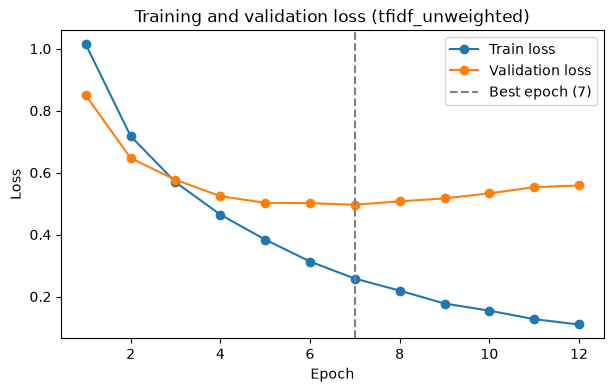

In [18]:
plot_loss_curves(best["train_losses"], best["val_losses"], model_name=best["name"])

Validation loss reaches its minimum at epoch 7.

### 5.2 Metrics on the test set

In [19]:
best_loaders = tfidf_loaders if best["name"].startswith("tfidf") else w2v_loaders
y_true, y_pred = evaluate_model(best["model"], best_loaders[2], class_names)

Accuracy: 0.7818

              precision    recall  f1-score   support

    negative     0.8647    0.8609    0.8628       906
     neutral     0.5929    0.5646    0.5784       294
    positive     0.6904    0.7466    0.7174       221

    accuracy                         0.7818      1421
   macro avg     0.7160    0.7241    0.7195      1421
weighted avg     0.7814    0.7818    0.7814      1421



### 5.3 Confusion matrix

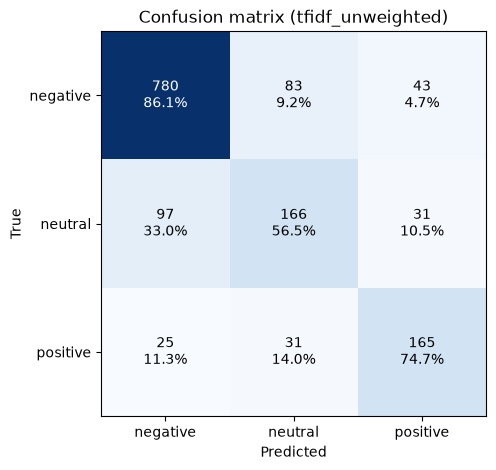

In [20]:
plot_confusion_matrix(y_true, y_pred, class_names, model_name=best["name"])